In [1]:
import igraph as ig
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

In [2]:
g = ig.Graph.Read_GraphML("../reports/grafo.graphml")
print(f"Quantidade de nós: {g.vcount()}")
print(f"Quantidade de arestas: {g.ecount()}")


Quantidade de nós: 4738
Quantidade de arestas: 10973326


/tmp/ipykernel_2991257/3942403460.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counter_pesos.keys()), y=list(counter_pesos.values()), palette="viridis")


(0.0, 10.0)

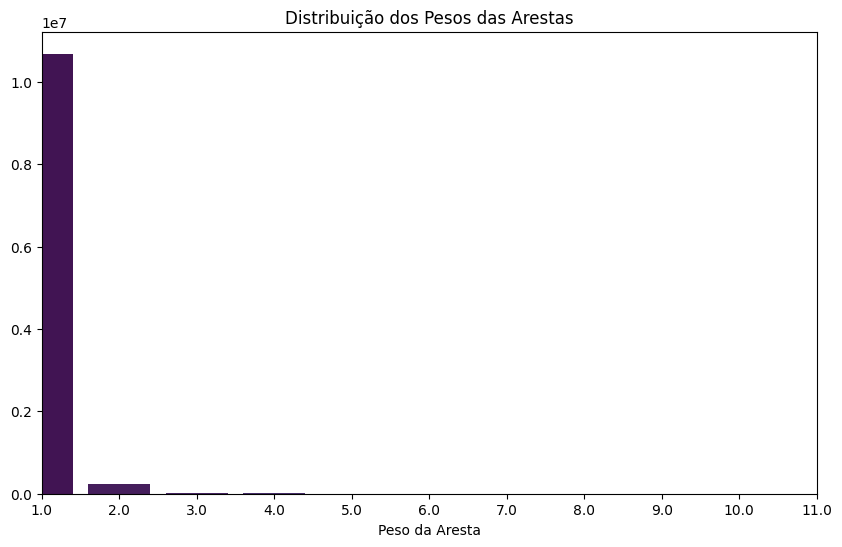

In [9]:
counter_pesos = Counter(g.es["weight"])
plt.figure(figsize=(10, 6))
sns.barplot(x=list(counter_pesos.keys()), y=list(counter_pesos.values()), palette="viridis")
plt.title("Distribuição dos Pesos das Arestas")
plt.xlabel("Peso da Aresta")
plt.xlim(0,10)

Text(0, 0.5, 'Frequência')

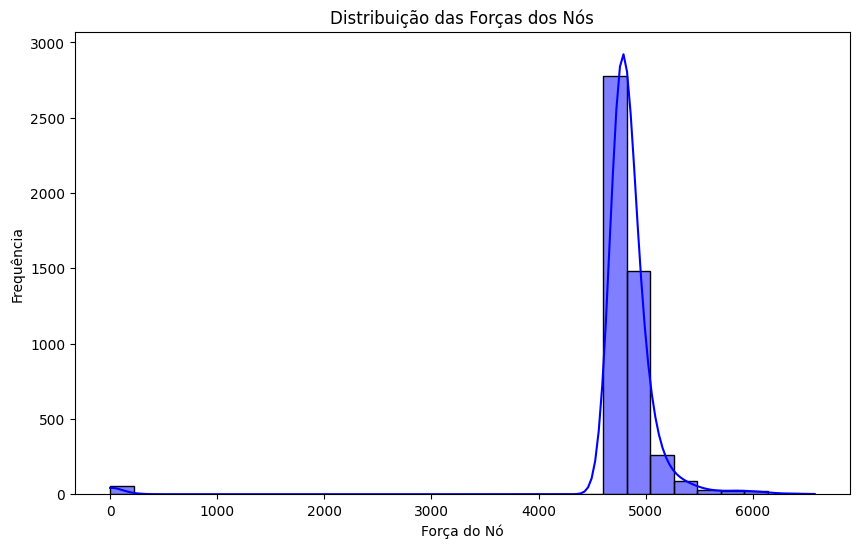

In [11]:
forcas = np.array(g.strength(weights='weight'))
plt.figure(figsize=(10, 6))
sns.histplot(forcas, bins=30, kde=True, color="blue")
plt.title("Distribuição das Forças dos Nós")
plt.xlabel("Força do Nó")
plt.ylabel("Frequência")

In [13]:
arestas_fortes = g.es.select(weight_ge=2)
g = g.subgraph_edges(arestas_fortes, delete_vertices=True)

In [16]:
print(f"Quantidade de nós: {g.vcount()}")
print(f"Quantidade de arestas: {g.ecount()}")

Quantidade de nós: 4701
Quantidade de arestas: 290504


Text(0, 0.5, 'Frequência')

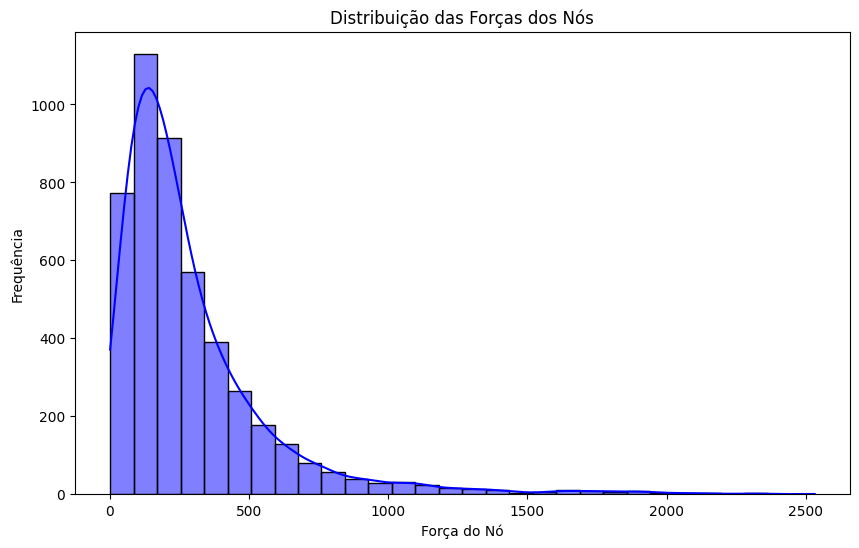

In [15]:
forcas = np.array(g.strength(weights='weight'))
plt.figure(figsize=(10, 6))
sns.histplot(forcas, bins=30, kde=True, color="blue")
plt.title("Distribuição das Forças dos Nós")
plt.xlabel("Força do Nó")
plt.ylabel("Frequência")

---
#### **1.Distribuição de graus**
A distribuição de grau é a fração de vértices da rede que possui um determinado grau. 
O grau de um vértice é o número de conexões (arestas) que ele tem com outros vértices.

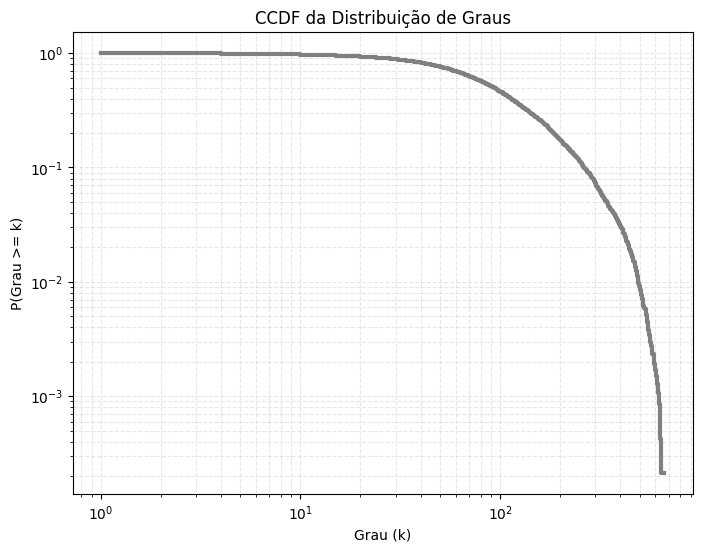

In [46]:
graus = g.degree()
contagem = Counter(graus)
graus_unicos = sorted(contagem.keys(), reverse=True)

y = {}
acumulado = 0
total_nos = g.vcount()

for k in graus_unicos:
    acumulado += contagem[k]
    y[k] = acumulado / total_nos

x_plot = sorted(y.keys())
y_plot = [y[k] for k in x_plot]

plt.figure(figsize=(8, 6))
plt.step(x_plot, y_plot, color='gray', linewidth=3) 
plt.xscale('log')
plt.yscale('log') 
plt.xlabel("Grau (k)")
plt.ylabel("P(Grau >= k)")
plt.title("CCDF da Distribuição de Graus")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

---
#### **2. Coeficiente de clusterização**

In [18]:
cc_values = g.transitivity_local_undirected()

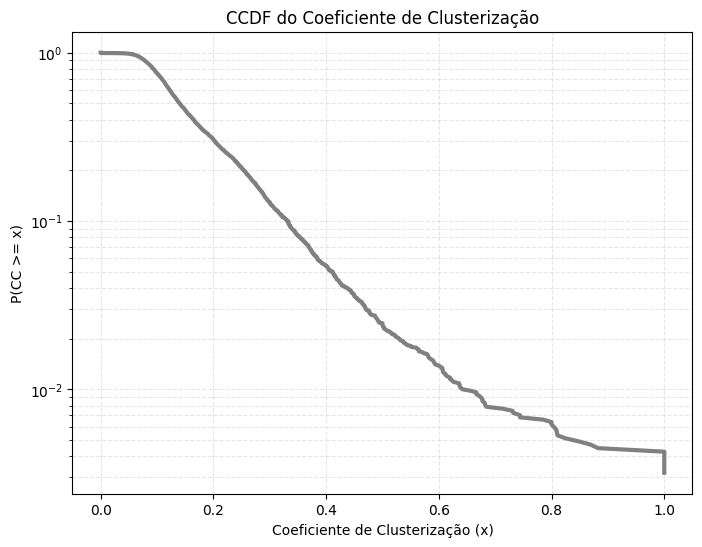

In [42]:
valores_cc = np.sort(cc_values)
n = len(valores_cc)
p_ccdf = np.linspace(1, 1/n, n)

plt.figure(figsize=(8, 6))
plt.plot(valores_cc, p_ccdf, color='gray', linewidth=3) 
plt.xscale('linear') 
plt.yscale('log')    
plt.xlabel("Coeficiente de Clusterização (x)")
plt.ylabel("P(CC >= x)")
plt.title("CCDF do Coeficiente de Clusterização")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

---
#### **3.Analisando a Centralidade dos Vértices**

A análise de centralidade serve para identificar a importância relativa de cada nó dentro da rede. No contexto de grafos de subreddits, diferentes métricas revelam diferentes comportamentos de influência e compartilhamento de usuários.

O que é Centralidade?
Em termos simples, a centralidade indica o quão "bem posicionado" um vértice está. No entanto, o conceito de "importância" é subjetivo e depende da métrica utilizada:

**Tipos de Centralidade**
1. Centralidade de Grau (Degree Centrality)
- É a medida mais simples e direta. Ela conta o número de conexões (arestas) que um vértice possui.Representa a versatilidade de um subreddit. Um valor alto indica um subreddit que compartilha pelo menos um autor com muitos outros subreddits.

- Significado: "Quem tem mais vizinhos?"

2. Centralidade de Força (Strength / Weighted Degree)
- Diferente do grau, a força leva em conta o peso das arestas. Ela soma o valor de todos os pesos das conexões de um nó. Representa o volume total de "tráfego" de usuários. Um subreddit pode ter poucas conexões, mas se essas conexões tiverem milhares de autores em comum, sua força será altíssima.

- Significado: "Quem tem as conexões mais intensas?"

3. Centralidade de Autovetor (Eigenvector Centrality)
- Esta métrica atribui importância a um nó com base na importância de seus vizinhos. É uma medida de influência "bem relacionada". Identifica subreddits que estão no "core" da rede. Estar conectado a um subreddit gigante aumenta mais a sua centralidade de autovetor do que estar conectado a vários subreddits isolados.

- Significado: "Quem está conectado a pessoas importantes?"

In [20]:
n = g.vcount()
graus = np.array(g.degree())
centralidade_grau = graus / (n - 1)

In [21]:
forcas = np.array(g.strength(weights='weight'))
total_pesos_rede = sum(g.es['weight'])

centralidade_forca = forcas / total_pesos_rede

In [22]:
centralidade_autovetor = g.eigenvector_centrality(weights='weight')

---
### **Figura da rede com os tamanhos dos vértices proporcionais às centralidades**

Calculando layout... Isso pode levar um minuto para 200k arestas.


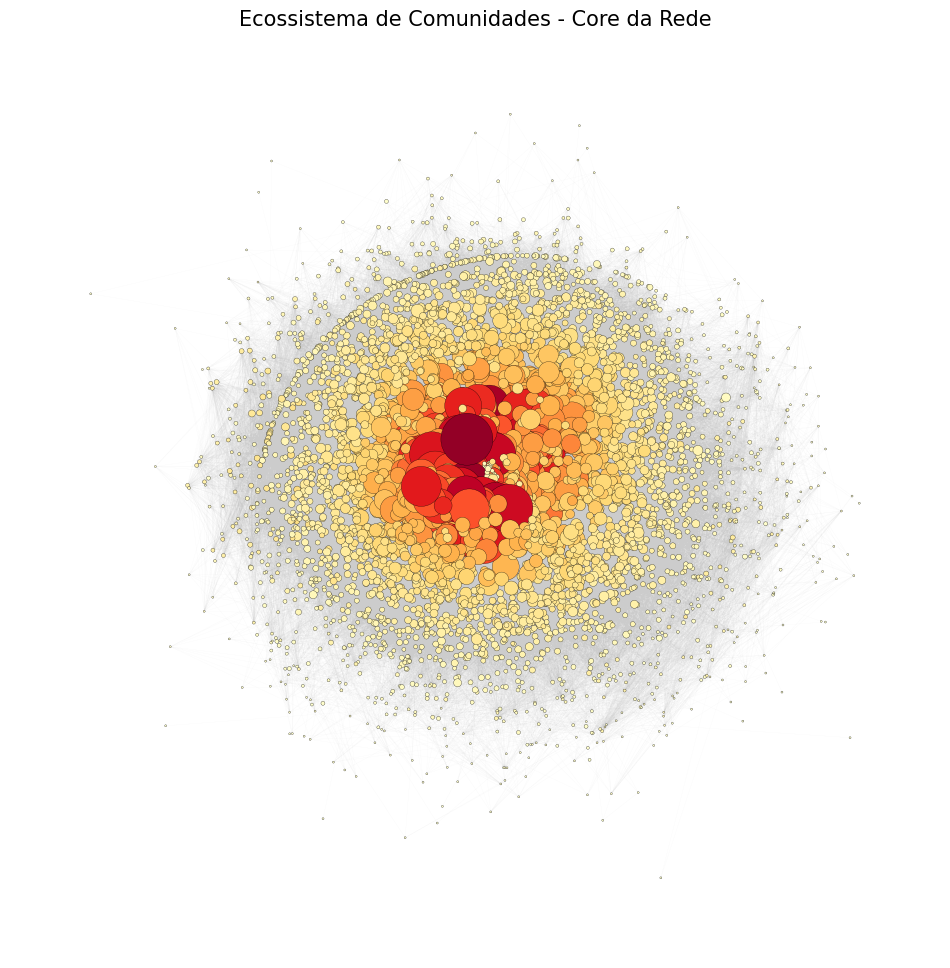

In [24]:
layout = g.layout("kk") 
fig, ax = plt.subplots(figsize=(12, 12))

sizes = [np.sqrt(v) * 50 + 2 for v in g.vs['eigen']]

import matplotlib.cm as cm
norm = plt.Normalize(vmin=min(g.vs['degree']), vmax=max(g.vs['degree']))
colors = [cm.YlOrRd(norm(d)) for d in g.vs['degree']]

ig.plot(
    g,
    target=ax,
    layout=layout,
    vertex_size=sizes,
    vertex_color=colors,
    vertex_frame_width=0.2,
    edge_width=0.1, 
    edge_color="#cccccc44",
    vertex_label=None, 
)

plt.title("Ecossistema de Comunidades - Core da Rede", fontsize=15)
plt.axis('off')
plt.show()

In [52]:
import os
import json
import pandas as pd

In [53]:
rows = []
erros = []

# Itera por cada profundidade
for depth in range(3 + 1):
    dir_ = f"../data/raw/final/{depth}/subreddits"
    if not os.path.exists(dir_):
        continue
    for filename in os.listdir(dir_):
        if filename.endswith(".json"):
            path = os.path.join(dir_, filename)
            try:
                with open(path, "r", encoding="utf-8") as f:
                    posts = json.load(f)
                # Adiciona a profundidade em cada post para rastreabilidade
                for post in posts:
                    post["depth"] = depth
                rows.extend(posts)
            except json.JSONDecodeError:
                erros.append(path)


df = pd.DataFrame(rows)

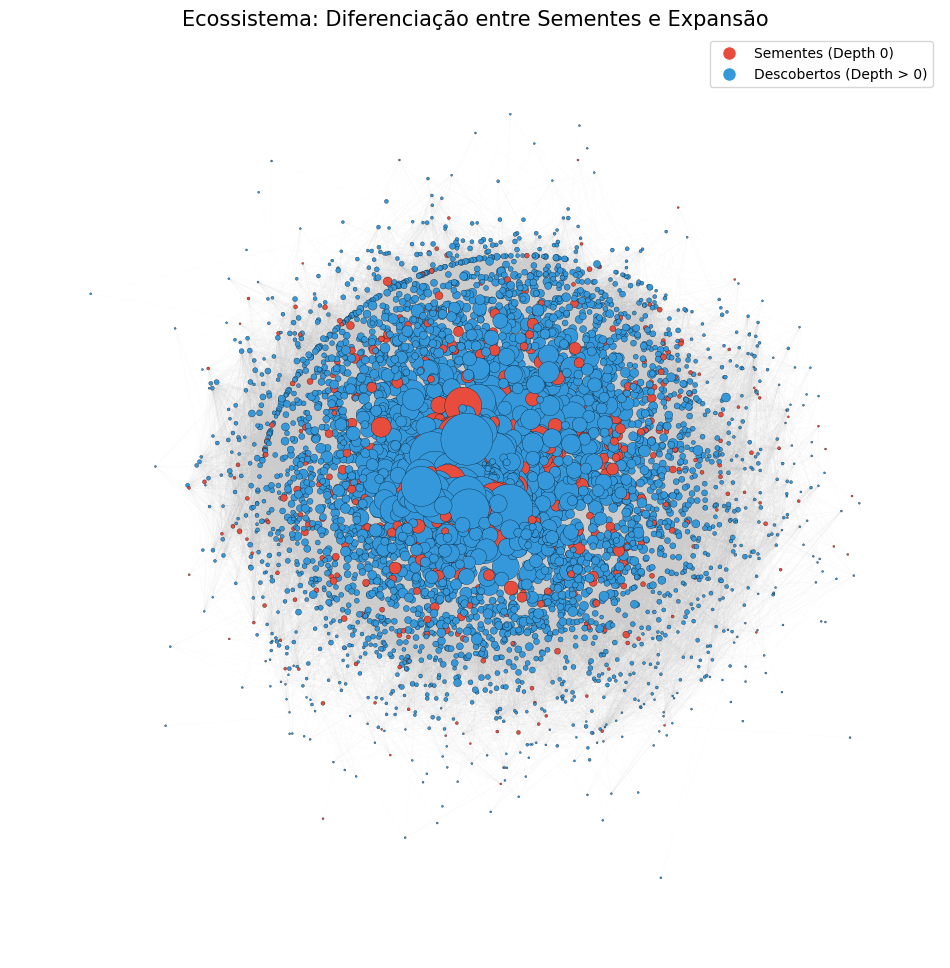

In [58]:
df_depths = df.groupby('subreddit')['depth'].min().reset_index()
depth_map = dict(zip(df_depths['subreddit'], df_depths['depth']))

vertex_colors = []
for name in g.vs['name']:
    depth = depth_map.get(name, 1) # Padrão 1 se não encontrar
    if depth == 0:
        vertex_colors.append("#e74c3c") # Vermelho vibrante para sementes
    else:
        vertex_colors.append("#3498db") # Azul para o restante

# 3. Preparar o Plot
layout = g.layout("kk") 
fig, ax = plt.subplots(figsize=(12, 12))

# Mantendo sua lógica de tamanho por Eigenvector
sizes = [np.sqrt(v) * 50 + 2 for v in g.vs['eigen']]

ig.plot(
    g,
    target=ax,
    layout=layout,
    vertex_size=sizes,
    vertex_color=vertex_colors, # AQUI USAMOS A NOVA LISTA DE CORES
    vertex_frame_width=0.2,
    edge_width=0.1, 
    edge_color="#cccccc44",
    vertex_label=None, 
)

# Adicionar uma legenda manual para facilitar a leitura
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Sementes (Depth 0)', 
           markerfacecolor='#e74c3c', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Descobertos (Depth > 0)', 
           markerfacecolor='#3498db', markersize=10)
]
ax.legend(handles=legend_elements, loc='upper right')

plt.title("Ecossistema: Diferenciação entre Sementes e Expansão", fontsize=15)
plt.axis('off')
plt.show()
